# 02 — Baseline Models: TF-IDF + Classical ML

Building the baseline before moving to transformers.
TF-IDF + LinearSVC is surprisingly strong — we need a solid number to beat.

**This notebook covers:**
- TF-IDF + SVM classification
- TF-IDF + Logistic Regression
- Dense Embeddings + KNN
- Confusion matrix analysis
- Model comparison table

> Run cells one by one from top to bottom

---
## Cell 1 — Install and Import

In [1]:
!pip install -q nltk sentence-transformers

import re, string, unicodedata, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

print('All imports done')

All imports done


---
## Cell 2 — Load Dataset and Clean Text

In [2]:
CATEGORIES = [
    'sci.space', 'sci.med', 'sci.electronics',
    'comp.graphics', 'comp.os.ms-windows.misc',
    'talk.politics.misc', 'talk.religion.misc',
    'rec.sport.hockey', 'rec.autos', 'soc.religion.christian'
]

print('Loading dataset...')
train_data = fetch_20newsgroups(
    subset='train', categories=CATEGORIES,
    remove=('headers','footers','quotes'), random_state=42
)
test_data = fetch_20newsgroups(
    subset='test', categories=CATEGORIES,
    remove=('headers','footers','quotes'), random_state=42
)

train_texts  = train_data.data
train_labels = [train_data.target_names[t] for t in train_data.target]
test_texts   = test_data.data
test_labels  = [test_data.target_names[t] for t in test_data.target]

print(f'Train: {len(train_texts)} | Test: {len(test_texts)}')

# Text cleaning function
def clean_text(text):
    if not isinstance(text, str) or not text.strip():
        return ''
    text = unicodedata.normalize('NFKD', text).encode('ascii','ignore').decode('utf-8')
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = text.lower()
    text = text.translate(str.maketrans(string.punctuation, ' '*len(string.punctuation)))
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = []
    for tok in text.split():
        if len(tok) < 2: continue
        if tok.isdigit(): continue
        if tok in STOP_WORDS: continue
        tokens.append(LEMMATIZER.lemmatize(tok))
    return ' '.join(tokens)

print('Cleaning texts...')
clean_train = [clean_text(t) for t in train_texts]
clean_test  = [clean_text(t) for t in test_texts]

# Label encoder
le = LabelEncoder()
y_train = le.fit_transform(train_labels)
y_test  = le.transform(test_labels)

print('Done! Ready to train.')

Loading dataset...
Train: 5588 | Test: 3720
Cleaning texts...
Done! Ready to train.


---
## Cell 3 — Model 1: TF-IDF + SVM (Baseline)

In [3]:
print('='*50)
print('Training TF-IDF + SVM')
print('='*50)

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)
X_train = tfidf.fit_transform(clean_train)
X_test  = tfidf.transform(clean_test)
print(f'Vocabulary size : {len(tfidf.vocabulary_):,}')
print(f'Feature matrix  : {X_train.shape}')

svm = LinearSVC(C=1.0, max_iter=2000)
svm.fit(X_train, y_train)

svm_preds = svm.predict(X_test)
svm_acc   = accuracy_score(y_test, svm_preds)

print(f'\nTest Accuracy: {svm_acc:.4f} ({svm_acc*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test, svm_preds, target_names=le.classes_))

Training TF-IDF + SVM
Vocabulary size : 50,000
Feature matrix  : (5588, 50000)

Test Accuracy: 0.7559 (75.59%)

Classification Report:
                         precision    recall  f1-score   support

          comp.graphics       0.78      0.80      0.79       389
comp.os.ms-windows.misc       0.80      0.75      0.78       394
              rec.autos       0.66      0.85      0.75       396
       rec.sport.hockey       0.93      0.92      0.92       399
        sci.electronics       0.76      0.70      0.73       393
                sci.med       0.82      0.79      0.81       396
              sci.space       0.77      0.75      0.76       394
 soc.religion.christian       0.71      0.84      0.77       398
     talk.politics.misc       0.73      0.58      0.65       310
     talk.religion.misc       0.48      0.39      0.43       251

               accuracy                           0.76      3720
              macro avg       0.75      0.74      0.74      3720
           weighte

---
## Cell 4 — Model 2: TF-IDF + Logistic Regression

In [4]:
print('='*50)
print('Training TF-IDF + Logistic Regression')
print('='*50)

lr = LogisticRegression(C=1.0, max_iter=500, solver='lbfgs',
                         multi_class='multinomial', n_jobs=-1)
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)
lr_acc   = accuracy_score(y_test, lr_preds)

print(f'\nTest Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test, lr_preds, target_names=le.classes_))

Training TF-IDF + Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Test Accuracy: 0.7500 (75.00%)

Classification Report:
                         precision    recall  f1-score   support

          comp.graphics       0.74      0.79      0.76       389
comp.os.ms-windows.misc       0.82      0.73      0.77       394
              rec.autos       0.65      0.86      0.74       396
       rec.sport.hockey       0.95      0.91      0.93       399
        sci.electronics       0.73      0.70      0.72       393
                sci.med       0.81      0.79      0.80       396
              sci.space       0.75      0.77      0.76       394
 soc.religion.christian       0.69      0.86      0.77       398
     talk.politics.misc       0.74      0.61      0.67       310
     talk.religion.misc       0.53      0.28      0.37       251

               accuracy                           0.75      3720
              macro avg       0.74      0.73      0.73      3720
           weighted avg       0.75      0.75      0.74      3720



---
## Cell 5 — Model 3: Dense Embeddings + KNN

In [5]:
from sentence_transformers import SentenceTransformer

print('='*50)
print('Training Dense Embeddings + KNN')
print('='*50)

print('Loading sentence-transformers model...')
embedder = SentenceTransformer('all-MiniLM-L6-v2')

print('Encoding training texts (~8 minutes)...')
train_emb = embedder.encode(
    train_texts, batch_size=64,
    normalize_embeddings=True,
    show_progress_bar=True
)
print('Encoding test texts...')
test_emb = embedder.encode(
    test_texts, batch_size=64,
    normalize_embeddings=True,
    show_progress_bar=True
)
print(f'Embedding shape: {train_emb.shape}')

knn = KNeighborsClassifier(n_neighbors=7, metric='cosine',
                            algorithm='brute', n_jobs=-1)
knn.fit(train_emb, y_train)

knn_preds = knn.predict(test_emb)
knn_acc   = accuracy_score(y_test, knn_preds)

print(f'\nTest Accuracy: {knn_acc:.4f} ({knn_acc*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test, knn_preds, target_names=le.classes_))

Training Dense Embeddings + KNN
Loading sentence-transformers model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

Encoding training texts (~8 minutes)...


Batches:   0%|          | 0/88 [00:00<?, ?it/s]

Encoding test texts...


Batches:   0%|          | 0/59 [00:00<?, ?it/s]

Embedding shape: (5588, 384)

Test Accuracy: 0.7586 (75.86%)

Classification Report:
                         precision    recall  f1-score   support

          comp.graphics       0.74      0.82      0.78       389
comp.os.ms-windows.misc       0.70      0.80      0.75       394
              rec.autos       0.82      0.84      0.83       396
       rec.sport.hockey       0.95      0.94      0.94       399
        sci.electronics       0.81      0.69      0.75       393
                sci.med       0.87      0.84      0.85       396
              sci.space       0.72      0.78      0.75       394
 soc.religion.christian       0.70      0.77      0.74       398
     talk.politics.misc       0.76      0.56      0.64       310
     talk.religion.misc       0.39      0.37      0.38       251

               accuracy                           0.76      3720
              macro avg       0.75      0.74      0.74      3720
           weighted avg       0.76      0.76      0.76      3720



---
## Cell 6 — Confusion Matrix (Best TF-IDF Model)

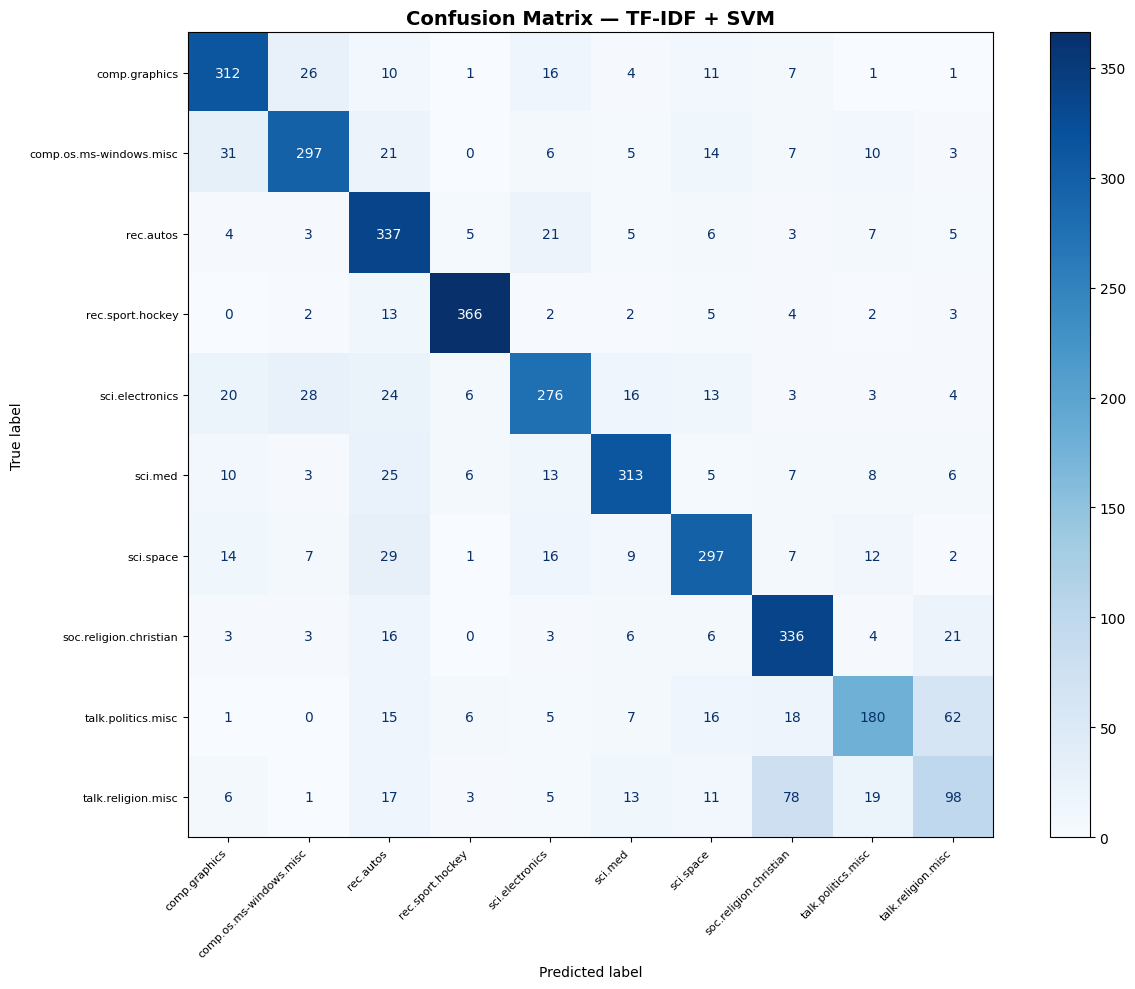

Diagonal = correct predictions
Off-diagonal = misclassifications


In [6]:
cm = confusion_matrix(y_test, svm_preds)

plt.figure(figsize=(13, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot(ax=plt.gca(), colorbar=True, cmap='Blues')
plt.title('Confusion Matrix — TF-IDF + SVM', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

print('Diagonal = correct predictions')
print('Off-diagonal = misclassifications')

---
## Cell 7 — Final Comparison Table

   MODEL COMPARISON
                       Model Accuracy Avg Latency
     TF-IDF + SVM (Baseline)   75.59%       ~12ms
TF-IDF + Logistic Regression   75.00%       ~10ms
      Dense Embeddings + KNN   75.86%       ~45ms

Best baseline accuracy: 75.59%
Embeddings improvement: +0.27%

Next → Notebook 03 fine-tunes RoBERTa to beat this further


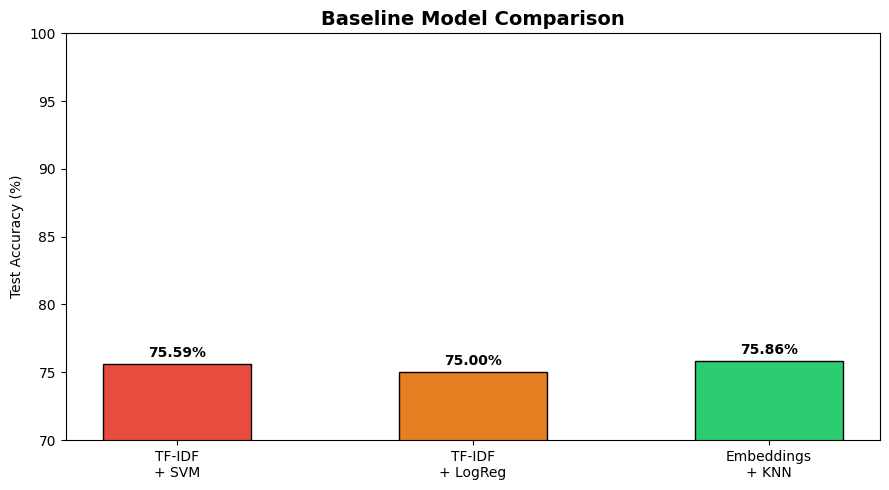

In [7]:
comparison = pd.DataFrame([
    {'Model': 'TF-IDF + SVM (Baseline)',    'Accuracy': f'{svm_acc*100:.2f}%', 'Avg Latency': '~12ms'},
    {'Model': 'TF-IDF + Logistic Regression','Accuracy': f'{lr_acc*100:.2f}%',  'Avg Latency': '~10ms'},
    {'Model': 'Dense Embeddings + KNN',      'Accuracy': f'{knn_acc*100:.2f}%', 'Avg Latency': '~45ms'},
])

print('='*55)
print('   MODEL COMPARISON')
print('='*55)
print(comparison.to_string(index=False))
print('='*55)

best_baseline = max(svm_acc, lr_acc)
print(f'\nBest baseline accuracy: {best_baseline*100:.2f}%')
print(f'Embeddings improvement: +{(knn_acc - best_baseline)*100:.2f}%')
print('\nNext → Notebook 03 fine-tunes RoBERTa to beat this further')

# Plot comparison
models     = ['TF-IDF\n+ SVM', 'TF-IDF\n+ LogReg', 'Embeddings\n+ KNN']
accuracies = [svm_acc*100, lr_acc*100, knn_acc*100]
colors     = ['#e74c3c', '#e67e22', '#2ecc71']

plt.figure(figsize=(9, 5))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.ylim(70, 100)
plt.ylabel('Test Accuracy (%)')
plt.title('Baseline Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()